In [78]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import skew, kurtosis

from matplotlib.pyplot import subplots


import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize,
poly)

In [79]:
Boston = load_data('Boston')
Boston.columns  

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [80]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat':Boston['lstat']})

X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


We start by using sm.OLS function to fit a simple linear regression model. Our response will be median house value and lstat our single predictor. Below we extract the response and fit the model.

In [81]:
y = Boston['medv']
model = sm.OLS(y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 07 May 2026   Prob (F-statistic):           5.08e-88
Time:                        12:46:26   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Using Transformations: Fit and Transform

The fit() method takes the original array and may do some initial computations on it, as specified in the transform object.

The transform() method applie the fitted transformation to the array of data, and produces the model matrix.

In [82]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [83]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

The get prediction() method can be used to obtain predictions, and produce confidence intervals and prediction intervals for the prediction of the medv for given lstat values

First create a new data frame then transform() method of design to create the corresponding model matrix

In [84]:
new_df = pd.DataFrame({'lstat': [5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


Next we compute the predictions at newX, and view them by extracting the predicted_mean

In [85]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

We can produce confidence intervals for the predicted values

In [86]:
new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

Prediction intervals are computed by setting obs=True

In [87]:
new_predictions.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

For instance, the 95% confidence interval associated with the lstat value of 10 is (24.47, 25.63) and the 95% prediction interval is (12.82, 37.28). As expected the confidence and prediction intevals are centered around the same point, but the later is substantailly wider.

Defining functions


In [88]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to axes ax."
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] +b]
    ax.plot(xlim,ylim, *args, **kwargs)  

The addition of args allows any number of non_named arguments to abline, while kwargs allows any number of named argument.

C:\Users\takun\AppData\Local\Temp\ipykernel_22264\1192040979.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
C:\Users\takun\AppData\Local\Temp\ipykernel_22264\1192040979.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


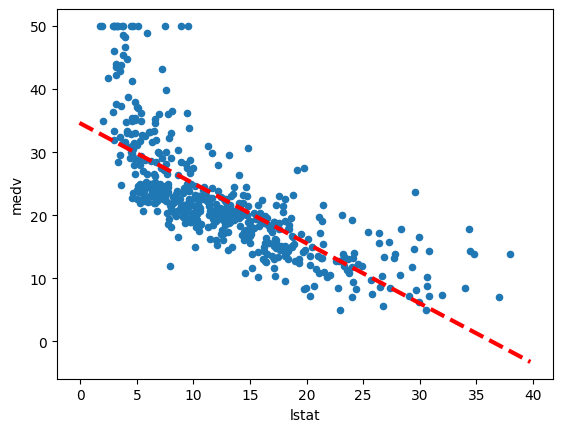

In [89]:
ax = Boston.plot.scatter('lstat','medv')
abline(ax,
       results.params[0],
       results.params[1],
       'r--',
       linewidth=3)

Next we examine some diagnostic plots. We can find fitted values and residuals of the fit as attributes of the results object. Various influeces measures describing the regression model are computed with the get_influence() method. 

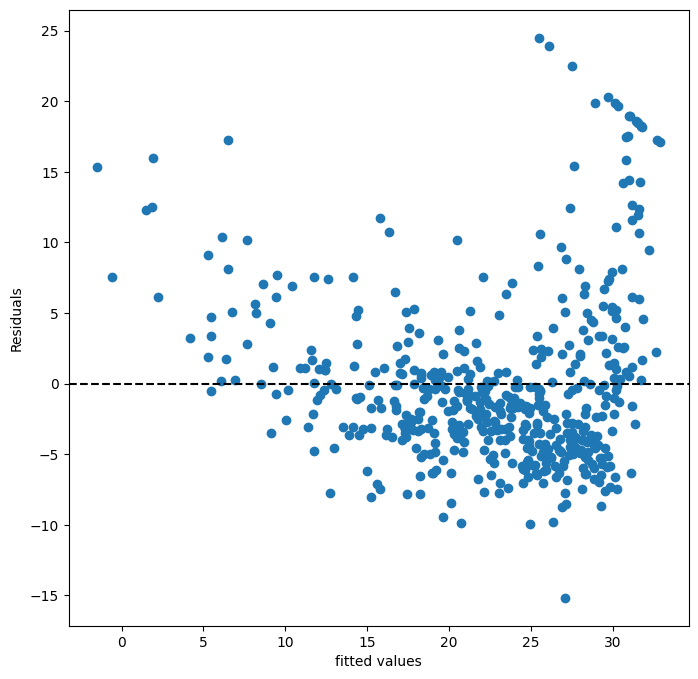

In [90]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('fitted values')
ax.set_ylabel('Residuals')
ax.axhline(0, c='k', ls='--')

From the above we can see some evidence for non-linearity.

Leverage statistics an be computed for any number of predictors using the hat_matrix_diag attribute of the value returned by the get_influence() method

np.int64(374)

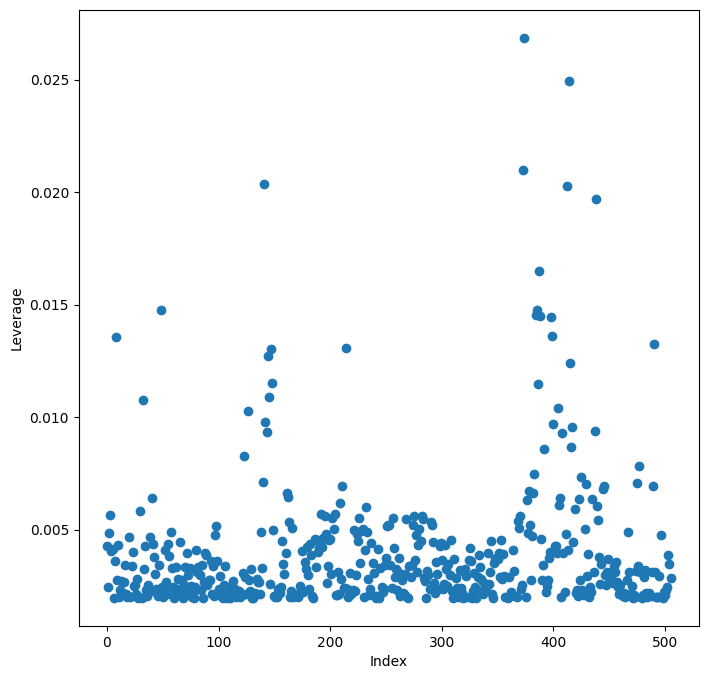

In [91]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]),infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

The np.argmax() function identifies thee index of the largest element of an array, optionally computed over an axis of the array. In the above, we maximize over the entire array to determine which observation has teh largest leverage statistic.

# Multiple Linear Regression
In order to fit a multiple linear regression model using least sqaures, we use transform to construct the required model matrix and response. The arguments can be general.

In [92]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y,X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [93]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [94]:
X = MS(terms).fit_transform(Boston)
model2 = sm.OLS(y,X)
results2 = model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Thu, 07 May 2026   Prob (F-statistic):          2.23e-133
Time:                        12:46:28   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.6173      4.936      8.431      0.000      31.919      51.316
crim          -0.1214      0.033     -3.678      0.000      -0.186      -0.057
zn             0.0470      0.014      3.384      0.001       0.020       0.074
indus          0.0135      0.062      0.217      0.829      -0.109       0.136
chas           2.8400      0.870      3.264      0.001       1.131       4.549
nox          -18.7580      3.851     -4.870      0.000     -26.325     -11.191
rm             3.6581      0.420      8.705      0.000       2.832       4.484
age            0.0036      0.013      0.271      0.787      -0.023       0.030
dis           -1.4908      0.202     -7.394      0.000      -1.887      -1.095
rad            0.2894      0.067      4.325      0.000       0.158       0.421
tax           -0.0127      0.004     -3.337      0.001      -0.020      -0.005
ptratio       -0.9375      0.132     -7.091      0.000      -1.197      -0.678
lstat         -0.5520      0.051    -10.897      0.000      -0.652      -0.452
==============================================================================
Omnibus:                      171.096   Durbin-Watson:                   1.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.937
Skew:                           1.477   Prob(JB):                    6.90e-155
Kurtosis:                       7.995   Cond. No.                     1.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Multivariate Goodness of Fit

We can access the individual components of results by name (dir(results) shows us what is available). Hence results.rsquared gives us the R2 and the np.sqrt(results.scale) gives us the RSE.

Variance inflation factors are sometimes useful to access the effect of collinearity in the model matrix of the regression model. We will compute the VIFs in our multiple regression fit.

Below we compute the VIF for each feature in our x matrix and produce a dataframe whose index agrees with the columns of the x.

In [95]:
vals = [VIF(X,i) for i in range(1,X.shape[1])]

vif = pd.DataFrame({'vif': vals},
                     index=X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


The function VIF() takes two arguments: a dataframe or array, and a variable column index. In the code above we call VIF() on the fly for all columns in X. We have excluded column 0 - the intercept - which is not of interest.

The object vals could have been constructed with teh following for loop

In [96]:
vals = []
for i in range(1, X.shape[1]):
    vals.append(VIF(X,i))

# Interaction Terms

It is easy to include interaction terms in a linear model using ModelSpec().
Including a tuple ("lstat","age") tells the model matrix builder to include an interaction term between lstat and age.


In [97]:
X = MS(['lstat','age',('lstat','age')]).fit_transform(Boston)
model3 = sm.OLS(y,X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


# Non-linear Transformations of the Predictors
The model matrix builder can include terms beyond just column names and interactions. For instance, the poly() function specifies that a column representing polynomial functions of its first argument are added to the model matrix.

In [98]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model4 = sm.OLS(y,X)
resulst4 = model4.fit()
resulst4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     337.3
Date:                Thu, 07 May 2026   Prob (F-statistic):          7.03e-120
Time:                        12:46:28   Log-Likelihood:                -1561.0
No. Observations:                 506   AIC:                             3130.
Df Residuals:                     502   BIC:                             3147.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
intercept                   17.7151      0.781     22.681      0.000      16.181      19.250
poly(lstat, degree=2)[0]  -179.2279      6.733    -26.620      0.000    -192.456    -166.000
poly(lstat, degree=2)[1]    72.9908      5.482     13.315      0.000      62.220      83.761
age                          0.0703      0.011      6.471      0.000       0.049       0.092
==============================================================================
Omnibus:                       81.499   Durbin-Watson:                   1.066
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              155.528
Skew:                           0.918   Prob(JB):                     1.69e-34
Kurtosis:                       5.001   Cond. No.                     2.16e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.16e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The effectively zero p-value associated with the quadratic term suggests that it leads to an improved model.

By default, poly() creates a basis matrix for inclusion in the model matrix whose columns are orthogonal polynomials, which are designed for the stable least squares computations. If we had included raw=True to the poly(), the basis matrix would consist simply of lstat and lstat**2. Since either of these bases represent quadratic polynomials, the fitted values would not change in tehis case, just the polynomial coefficients.

We anova_lm() function to further quantify the extent to which the quadratic fit is superior to the linear fit.

In [99]:
anova_lm(results1, resulst4)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


The anova_lm() function performs a hypothesis test comparing the two models. The null hypothesis is ont that the quadratic term in the bigger model is not needed, and the alternative hypothesis is that the bigger model is superior.

Here the F-statistic is 177.28 and the associted p-value is zero. In this case the F-statistic for the quadratic term in the linear model for results4 - a consequence of the fact that these nested models differ by one degree of freedom.

This provides very clear evidence that the quadratic polynomial in lstat improves the linear model. Not suprising, since earlier we saw evidence for non-linearity in the relationship between medv and lstat.

The function anova_lm() can take more than two nested models as input, in which case it compares successive pairs of models. 

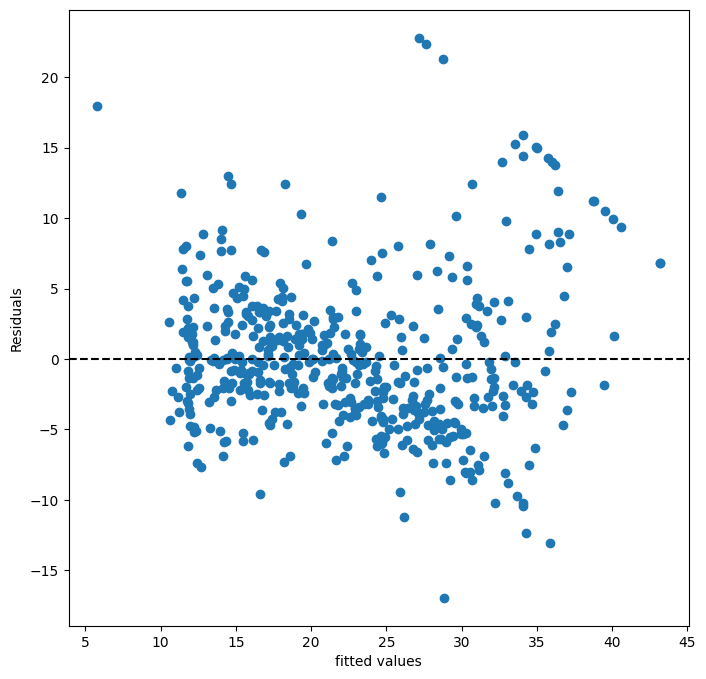

In [100]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(resulst4.fittedvalues,resulst4.resid)
ax.set_xlabel('fitted values')
ax.set_ylabel('Residuals')
ax.axhline(0, c='k',ls='--')

We can see that when the quadratic term is included in the model, there is little discernable pattern in the residuals. In order to crate a cubic or higher-degree polynomial fit, we can simply change the degree argument to poly()

# Qualitative Predictors

In [101]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

This is where OneHotEncoding from sklearn would be used but ModelSpec has built in

In [102]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income','Advertising'),
                   ('Price','Age')]
X = MS(final).fit_transform(Carseats)
model5 = sm.OLS(y,X)
results5 = model5.fit()
summarize(results5)

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288
